In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
import seaborn as sns

In [91]:
df = pd.read_excel("qldpc_result.xlsx", sheet_name="square")
methods = ["sabre-cx", "sabre-stab", "canopus-cx", "canopus-stab"]
method_label_names = {"sabre-cx": "Sabre (CX)", "sabre-stab": "Sabre (CX-iSWAP)", "canopus-cx": "Canopus (CX)", "canopus-stab": "Canopus (CX-iSWAP)"}
rename_dict = {
    "BBCode1": "BB [[18, 4, 4]]",
    "BBCode2": "BB [[36, 4, 6]]",
    "GBCode1": "GB [[18, 2, 5]]",
    "GBCode2": "GB [[30, 2, 5]]",
    "GBCode3": "GB [[36, 2, 6]]",
}
df = df[df['code name'] != 'GBCode2']
df['round'] = df['code name'].apply(lambda name: int(rename_dict[name][-3]))
df['LER(qc)'] /= df['round']
for method in methods:
    df[f'LER({method})'] /= df['round']
df.drop(['round', 'duration(qc)', 'LER(qc)'] + [f'duration({method})' for method in methods], inplace=True, axis=1)

In [92]:
grouped = df.groupby('code name').agg(['mean', 'std'])
grouped

LER(sabre-cx)           LER(sabre-stab)           LER(canopus-cx)  \
                   mean       std            mean       std            mean   
code name                                                                     
BBCode1        0.037210  0.004329        0.023117  0.003341        0.019683   
BBCode2        0.038955  0.006034        0.022400  0.003838        0.018287   
GBCode1        0.013192  0.003288        0.009616  0.002604        0.008933   
GBCode3        0.009042  0.002275        0.003608  0.001626        0.002371   

                    LER(canopus-stab)            
                std              mean       std  
code name                                        
BBCode1    0.003196          0.011298  0.003011  
BBCode2    0.001248          0.009697  0.001419  
GBCode1    0.002060          0.006667  0.002182  
GBCode3    0.000171          0.000512  0.000029

In [108]:
from scipy.stats import gmean

data = grouped.to_numpy()

print('CX: error rate reduction', gmean(np.abs((data[:,4] - data[:,0])) / data[:,0]))
print('CX-iSWAP: error rate reduction', gmean(np.abs((data[:,6] - data[:,2])) / data[:,2]))


CX: error rate reduction 0.49394869800189684
CX-iSWAP: error rate reduction 0.5255538208516841


In [87]:
method_label_names

{'sabre-cx': 'Sabre (CX)',
 'sabre-stab': 'Sabre (CX-iSWAP)',
 'canopus-cx': 'Canopus (CX)',
 'canopus-stab': 'Canopus (CX-iSWAP)'}

/var/folders/r5/1qhftv4d3_g432jmyr9vy6wc0000gn/T/ipykernel_45823/3691808224.py:5: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = grouped.stack(level=0).reset_index()


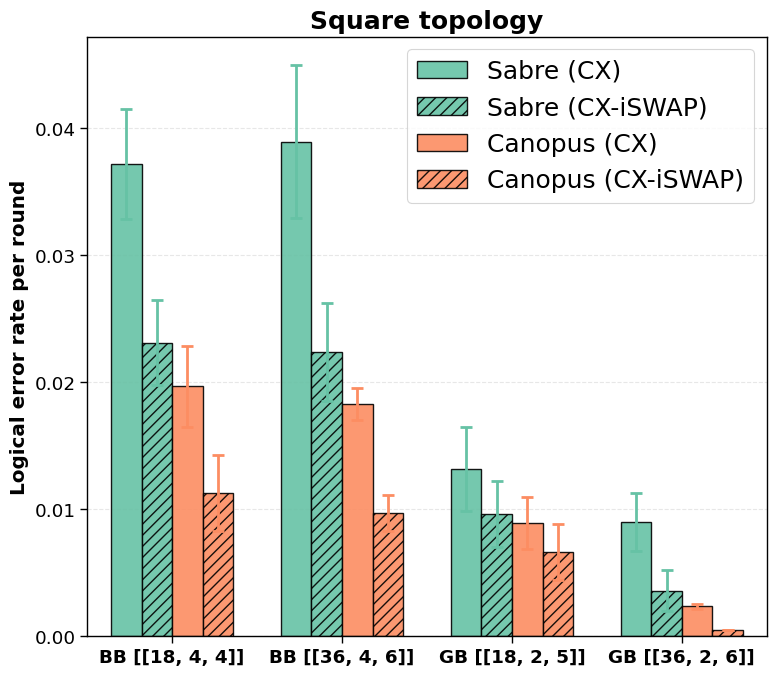

In [89]:
sns.set_context("paper", font_scale=1.5)

# plt.style.use('seaborn-v0_8-whitegrid')

stacked = grouped.stack(level=0).reset_index()
stacked.columns = ['code name', 'metric', 'mean', 'std']
stacked['code label'] = stacked['code name'].map(rename_dict)
base_colors = sns.color_palette('Set2', 2)
method_styles = [
    ('sabre-cx', base_colors[0], None),
    ('sabre-stab', base_colors[0], '///'),
    ('canopus-cx', base_colors[1], None),
    ('canopus-stab', base_colors[1], '///'),
]
metric_order = [f'LER({method})' for method, _, _ in method_styles]

code_order = [rename_dict[name] for name in grouped.index]
x = np.arange(len(code_order))
width = 0.18

fig, ax = plt.subplots(figsize=(8, 7))
for idx, (method, color, hatch) in enumerate(method_styles):
    metric = f'LER({method})'
    subset = stacked[stacked['metric'] == metric].set_index('code name').loc[grouped.index]
    offsets = x + (idx - (len(method_styles) - 1) / 2) * width
    bars = ax.bar(
        offsets,
        subset['mean'],
        width=width,
        yerr=subset['std'],
        color=color,
        edgecolor='k',
        linewidth=1,
        capsize=4,
        alpha=0.9,
        label=method_label_names[method],
        ecolor=color,
        error_kw={'elinewidth': 2, 'capthick': 2}
    )
    if hatch:
        for bar in bars:
            bar.set_hatch(hatch)

ax.set_xticks(x)
ax.set_xticklabels(code_order, rotation=0, ha='center', fontweight='bold')
ax.set_ylabel('Logical error rate per round', fontweight='bold')
# ax.set_title(r'Mean logical error rate ± 1$\sigma$ by compiler / encoding', fontsize=15, fontweight='bold')
# ax.legend(title='Method', ncol=2, frameon=False)
ax.legend(fontsize=18)
ax.set_xlim(-0.5, 3.5)
ax.grid(axis='y', linestyle='--', alpha=0.3)
# ax.set_yscale("log")

ax.set_axisbelow(True)
# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)

plt.title('Square topology', fontsize=18, fontweight='bold')
fig.tight_layout()
plt.savefig('../figures/ler_abs_topo_square.pdf')
plt.show()

In [78]:
df = pd.read_excel("qldpc_result.xlsx", sheet_name="hhex")
methods = ["sabre-cx", "sabre-stab", "canopus-cx", "canopus-stab"]
method_label_names = {"sabre-cx": "Sabre (CX)", "sabre-stab": "Sabre (CX-iSWAP)", "canopus-cx": "Canopus (CX)", "canopus-stab": "Canopus (CX-iSWAP)"}
rename_dict = {
    "BBCode1": "BB [[18, 4, 4]]",
    "BBCode2": "BB [[36, 4, 6]]",
    "GBCode1": "GB [[18, 2, 5]]",
    "GBCode2": "GB [[30, 2, 5]]",
    "GBCode3": "GB [[36, 2, 6]]",
}
df = df[df['code name'] != 'GBCode2']
df['round'] = df['code name'].apply(lambda name: int(rename_dict[name][-3]))
df['LER(qc)'] /= df['round']
for method in methods:
    df[f'LER({method})'] /= df['round']
df.drop(['round', 'duration(qc)', 'LER(qc)'] + [f'duration({method})' for method in methods], inplace=True, axis=1)

In [79]:
grouped = df.groupby('code name').agg(['mean', 'std'])
grouped

LER(sabre-cx)           LER(sabre-stab)           LER(canopus-cx)  \
                   mean       std            mean       std            mean   
code name                                                                     
BBCode1        0.056017  0.001319        0.035024  0.001171        0.048956   
BBCode2        0.065668  0.002443        0.044722  0.003605        0.055758   
GBCode1        0.028786  0.003664        0.021362  0.002737        0.025906   
GBCode3        0.018583  0.006099        0.007514  0.003015        0.016925   

                    LER(canopus-stab)            
                std              mean       std  
code name                                        
BBCode1    0.002829          0.029105  0.004269  
BBCode2    0.001501          0.023440  0.001101  
GBCode1    0.006091          0.017720  0.004109  
GBCode3    0.000627          0.003450  0.000312

/var/folders/r5/1qhftv4d3_g432jmyr9vy6wc0000gn/T/ipykernel_45823/3880779661.py:5: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = grouped.stack(level=0).reset_index()


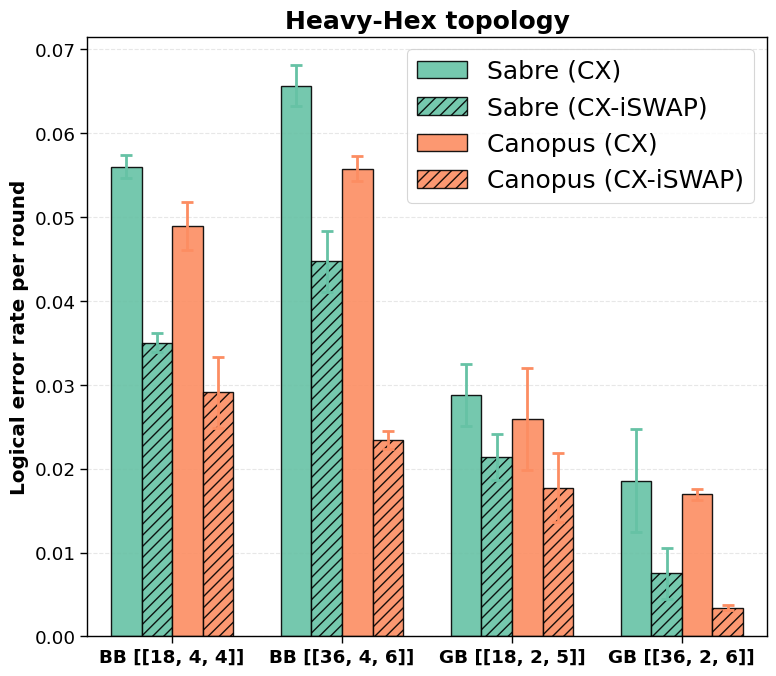

In [84]:
sns.set_context("paper", font_scale=1.5)

# plt.style.use('seaborn-v0_8-whitegrid')

stacked = grouped.stack(level=0).reset_index()
stacked.columns = ['code name', 'metric', 'mean', 'std']
stacked['code label'] = stacked['code name'].map(rename_dict)
base_colors = sns.color_palette('Set2', 2)
method_styles = [
    ('sabre-cx', base_colors[0], None),
    ('sabre-stab', base_colors[0], '///'),
    ('canopus-cx', base_colors[1], None),
    ('canopus-stab', base_colors[1], '///'),
]
metric_order = [f'LER({method})' for method, _, _ in method_styles]

code_order = [rename_dict[name] for name in grouped.index]
x = np.arange(len(code_order))
width = 0.18

fig, ax = plt.subplots(figsize=(8, 7))
for idx, (method, color, hatch) in enumerate(method_styles):
    metric = f'LER({method})'
    subset = stacked[stacked['metric'] == metric].set_index('code name').loc[grouped.index]
    offsets = x + (idx - (len(method_styles) - 1) / 2) * width
    bars = ax.bar(
        offsets,
        subset['mean'],
        width=width,
        yerr=subset['std'],
        color=color,
        edgecolor='k',
        linewidth=1,
        capsize=4,
        alpha=0.9,
        label=method_label_names[method],
        ecolor=color,
        error_kw={'elinewidth': 2, 'capthick': 2}
    )
    if hatch:
        for bar in bars:
            bar.set_hatch(hatch)

ax.set_xticks(x)
ax.set_xticklabels(code_order, rotation=0, ha='center', fontweight='bold')
ax.set_ylabel('Logical error rate per round', fontweight='bold')
# ax.set_title(r'Mean logical error rate ± 1$\sigma$ by compiler / encoding', fontsize=15, fontweight='bold')
# ax.legend(title='Method', ncol=2, frameon=False)
ax.legend(fontsize=18)
ax.set_xlim(-0.5, 3.5)
ax.grid(axis='y', linestyle='--', alpha=0.3)
# ax.set_yscale("log")

ax.set_axisbelow(True)
# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)

plt.title('Heavy-Hex topology', fontsize=18, fontweight='bold')
fig.tight_layout()

plt.savefig('../figures/ler_abs_topo_hhex.pdf')
plt.show()